# CUADERNO JUPYTER UNIFICADO: Práctica 1 – Metaheurísticas (Curso 2025/2026)
## Algoritmo 1: Búsqueda Aleatoria (Random Search)


## 1. Introducción

El objetivo de esta práctica es segmentar una serie temporal en *k* segmentos, ajustando en cada uno de ellos una regresión lineal independiente. La calidad de una segmentación se evalúa mediante el **RMSE medio** de todos los segmentos, que actúa como función objetivo a minimizar.

En este cuaderno se implementa el algoritmo **Random Search (RS)**, que servirá como punto de referencia (baseline) para comparar posteriormente con los métodos Hill Climbing (HC) y Simulated Annealing (SA).

Random Search es un método simple:  
- Genera segmentaciones aleatorias de la serie.  
- Evalúa su calidad mediante el RMSE medio.  
- Conserva la mejor solución encontrada durante el proceso.

Aunque no aprovecha información estructural del problema ni aplica mecanismos de mejora local, RS es útil como baseline porque permite establecer un rendimiento mínimo esperable. Esto facilita valorar de forma objetiva si los métodos más avanzados (HC y SA) aportan mejoras significativas en exactitud, estabilidad y tiempo de cómputo.


## 2. Importación de librerías

En esta sección se importan las librerías necesarias para:

- Manipulación numérica (`numpy`)
- Gestión de datos (`pandas`)
- Visualización (`matplotlib`, `seaborn`)
- Ajuste de regresiones lineales (`sklearn`)
- Medición del error (`mean_squared_error`)
- Generación de números aleatorios y medición de tiempos

Estas herramientas permiten implementar y evaluar el algoritmo Random Search.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import random
import time

## 3. Carga de series temporales

Se define una función auxiliar para leer los archivos de datos que contienen las series temporales TS1–TS4.  
Cada archivo contiene una lista de valores numéricos entre corchetes, por lo que es necesario limpiarlos antes de convertirlos a `float`.

Posteriormente, se cargan las cuatro series y se asocian con sus valores de *k* correspondientes:

- TS1 → k = 9  
- TS2 → k = 10  
- TS3 → k = 20  
- TS4 → k = 50  

Estas series serán utilizadas en los experimentos posteriores.

In [6]:
import os

def read_serie(path):

    with open(path, "r") as f:
        contenido = f.read().replace("[", "").replace("]", "").split()
        return [float(x) for x in contenido]

# Rutas correctas a tus archivos SIN extensión
files = [
    "../datos/TS1",
    "../datos/TS2",
    "../datos/TS3",
    "../datos/TS4"
]

series = [read_serie(f) for f in files]
k_values = [9, 10, 20, 50]
# TS1 → 9 segmentos
#  TS2 → 10 segmentos
#  TS3 → 20 segmentos
#  TS4 → 50 segmentos


print(" Series cargadas correctamente")

 Series cargadas correctamente


## 4. Regresión lineal por segmentos

El problema requiere ajustar una regresión lineal independiente en cada segmento definido por los puntos de corte.  
Para ello se implementan tres funciones:

### `estimate_segment_coef(x, y)`
Ajusta una recta a un segmento y devuelve sus coeficientes (pendiente y ordenada en el origen).

### `estimate_all_coef(serie, points)`
Calcula los coeficientes de todos los segmentos definidos por los puntos de corte.

### `estimate_all_points(coef, points, n)`
Reconstruye la serie estimada completa a partir de los coeficientes de cada segmento.

Estas funciones permiten evaluar la calidad de una segmentación mediante el cálculo del RMSE.


In [7]:
def estimate_segment_coef(x, y):
    x = np.array(x).reshape(-1, 1)
    y = np.array(y)

    if len(x) < 2:
        return (0.0, 0.0)

    model = LinearRegression().fit(x, y)
    return (model.coef_[0], model.intercept_)


def estimate_all_coef(serie, points):
    coef = []
    start = 0
    pts = points.copy()
    pts.append(len(serie))

    for end in pts:
        x = list(range(start, end))
        y = serie[start:end]
        coef.append(estimate_segment_coef(x, y))
        start = end

    return coef


def estimate_all_points(coef, points, n):
    estimated = []
    start = 0
    pts = points.copy()
    pts.append(n)

    for idx, end in enumerate(pts):
        m, b = coef[idx]
        for i in range(start, end):
            estimated.append(m * i + b)
        start = end

    return estimated

## 5. Generación de puntos de corte aleatorios

Random Search explora el espacio de soluciones generando particiones aleatorias de la serie.  
La función `randomPoints` genera un conjunto de puntos de corte sin repetición y ordenados, garantizando que los segmentos sean consecutivos y válidos.

In [8]:
# Este código genera puntos de corte aleatorios para dividir la serie temporal en segmentos.

def randomPoints(longitud_serie, n_cortes):
    b = []
    while n_cortes > 0:
        r = random.randint(1, longitud_serie - 1)
        if r not in b:
            b.append(r)
            n_cortes -= 1
    b.sort()
    return b

## 6. Cálculo del RMSE por segmento

Para evaluar la calidad de una segmentación se utiliza el **RMSE medio** de todos los segmentos.

### `RMSE(y_real, y_pred)`
Calcula el error cuadrático medio entre valores reales y estimados.

### `mean_rmse(serie, points)`
Calcula el RMSE medio de todos los segmentos definidos por los puntos de corte.

Este valor es el criterio que Random Search intenta minimizar.

In [9]:
def RMSE(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    return np.sqrt(mse)


def mean_rmse(serie, points):
    rmse_acc = 0.0
    start = 0

    coef = estimate_all_coef(serie, points.copy())
    estimated = estimate_all_points(coef, points.copy(), len(serie))

    pts = points.copy()
    pts.append(len(serie))

    for point in pts:
        rmse_acc += RMSE(serie[start:point], estimated[start:point])
        start = point

    return rmse_acc / len(pts)

## 7. Implementación del algoritmo Random Search (RS)

El algoritmo Random Search funciona de la siguiente manera:

1. Genera una segmentación aleatoria.
2. Calcula su RMSE medio.
3. Compara con la mejor solución encontrada hasta el momento.
4. Si mejora, actualiza la solución óptima.
5. Repite el proceso durante un número fijo de iteraciones.

La función `randomSearch` devuelve:
- La mejor segmentación encontrada
- Su RMSE asociado
- El tiempo total de ejecución
- El historial de mejoras

Este algoritmo sirve como referencia base para comparar con Hill Climbing y Simulated Annealing.

In [10]:
def randomSearch(serie, k, n_iter, prev_best=None):

    if prev_best is None:
        best = {'rmse': float('inf'), 'points': None}
    else:
        best = prev_best

    startTime = time.time()
    rmses = []

    for _ in range(n_iter):
        points = randomPoints(len(serie), k)
        rmse = mean_rmse(serie, points)

        if rmse < best['rmse']:
            best['rmse'] = rmse
            best['points'] = points
            rmses.append(best.copy())

    endTime = time.time()
    i_time = endTime - startTime

    return best, i_time, rmses

## 8. Ejecución del experimento

Para evaluar el rendimiento del algoritmo, se ejecuta Random Search:

- Sobre las cuatro series temporales
- Con un número creciente de iteraciones (10, 20, 30, ..., 190)
- Repitiendo el experimento 20 veces para medir variabilidad

La función `ejecutar_RS` almacena:
- RMSE final
- Puntos de corte óptimos
- Tiempo de ejecución
- Evolución del RMSE

Estos datos se utilizarán posteriormente para generar gráficas y métricas comparativas.

In [11]:
def ejecutar_RS(series, k_values, start=10, end=200, step=10, repeticiones=20):
    resultados = []
    print("\n === Ejecutando experimento Random Search === ")

    for rep in range(repeticiones):
        print(f"Repetición {rep+1}/{repeticiones} completada")
        rep_result = []

        for idx, serie in enumerate(series):
            k = k_values[idx]
            best = None
            serie_result = []

            for n in range(start, end, step):
                best, tiempo, historial = randomSearch(serie, k, step, best)
                serie_result.append({
                    "iter": n,
                    "rmse": best["rmse"],
                    "points": best["points"],
                    "tiempo": tiempo
                })

            rep_result.append(serie_result)

        resultados.append(rep_result)

    print(" === Experimento finalizado === \n")
    return resultados

## 8.1. Ejecución del experimento completo

In [12]:
resultados_RS = ejecutar_RS(series, k_values, start=10, end=200, step=10, repeticiones=20)


 === Ejecutando experimento Random Search === 
Repetición 1/20 completada
Repetición 2/20 completada
Repetición 3/20 completada
Repetición 4/20 completada
Repetición 5/20 completada
Repetición 6/20 completada
Repetición 7/20 completada
Repetición 8/20 completada
Repetición 9/20 completada
Repetición 10/20 completada
Repetición 11/20 completada
Repetición 12/20 completada
Repetición 13/20 completada
Repetición 14/20 completada
Repetición 15/20 completada
Repetición 16/20 completada
Repetición 17/20 completada
Repetición 18/20 completada
Repetición 19/20 completada
Repetición 20/20 completada
 === Experimento finalizado === 



## 9. Visualización de resultados

### 9.1. Evolución del **RMSE**

Este apartado muestra la evolución del error cuadrático medio (RMSE) a lo largo de las iteraciones del algoritmo **Random Search** para cada serie temporal.  
Las gráficas permiten analizar la estabilidad y la capacidad de mejora del método conforme aumenta el número de iteraciones.

**Cada gráfica incluye:**

- **Media del RMSE** obtenida en las 20 repeticiones del experimento.  
- **Banda de ±1 desviación típica**, que refleja la variabilidad del algoritmo.  
- **Marcadores de inicio y fin**, que destacan visualmente el comportamiento del método en los extremos del rango de iteraciones.

In [13]:
def plot_RS(series, resultados):
    print(">>> Generando gráficas de Búsqueda Aleatoria ... ")
    num_series = len(series)

    for idx in range(num_series):
        rmse_iters = np.array([
            [it["rmse"] for it in rep[idx]]
            for rep in resultados
        ])

        mean_rmse = rmse_iters.mean(axis=0)
        std_rmse = rmse_iters.std(axis=0)
        iters = [it["iter"] for it in resultados[0][idx]]

        plt.figure(figsize=(12, 5))
        plt.fill_between(iters, mean_rmse - std_rmse, mean_rmse + std_rmse,
                         color="#4A90E2", alpha=0.20, label="+1 desviación")

        plt.plot(iters, mean_rmse, color="#1F4E79", linewidth=2.2,
                 marker="o", markersize=5, label="Media RMSE")

        plt.scatter(iters[0], mean_rmse[0], color="green", s=80, label="Inicio")
        plt.scatter(iters[-1], mean_rmse[-1], color="red", s=80, label="Fin")

        plt.title(f"Evolución del RMSE - Random Search (TS{idx+1})", fontsize=14)
        plt.xlabel("Iteraciones")
        plt.ylabel("RMSE")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()

        plt.savefig(f"TS{idx+1}_mean.png", dpi=150)

        plt.show()

    print(">>> Gráficas generadas correctamente.")


>>> Generando gráficas de Búsqueda Aleatoria ... 


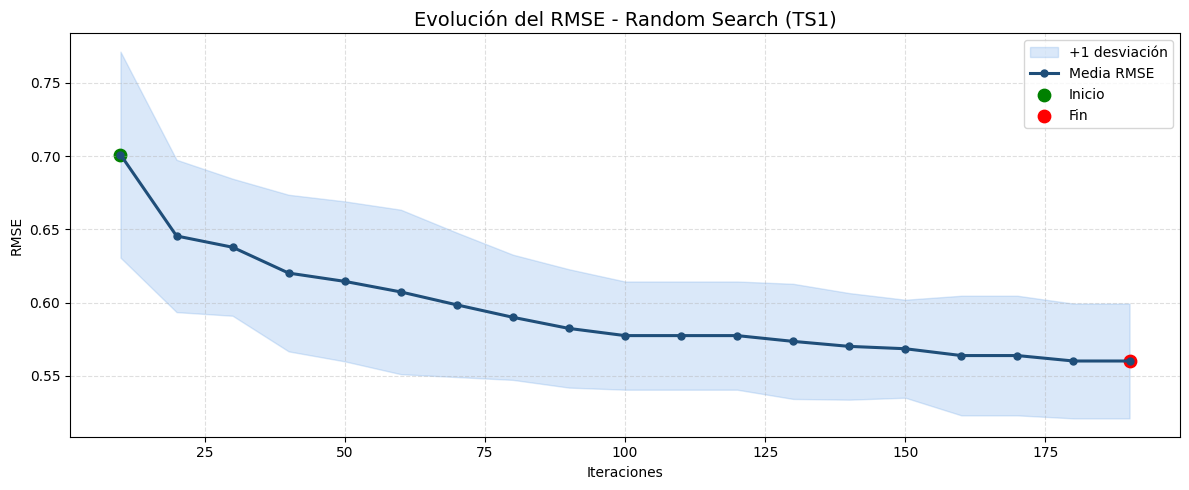

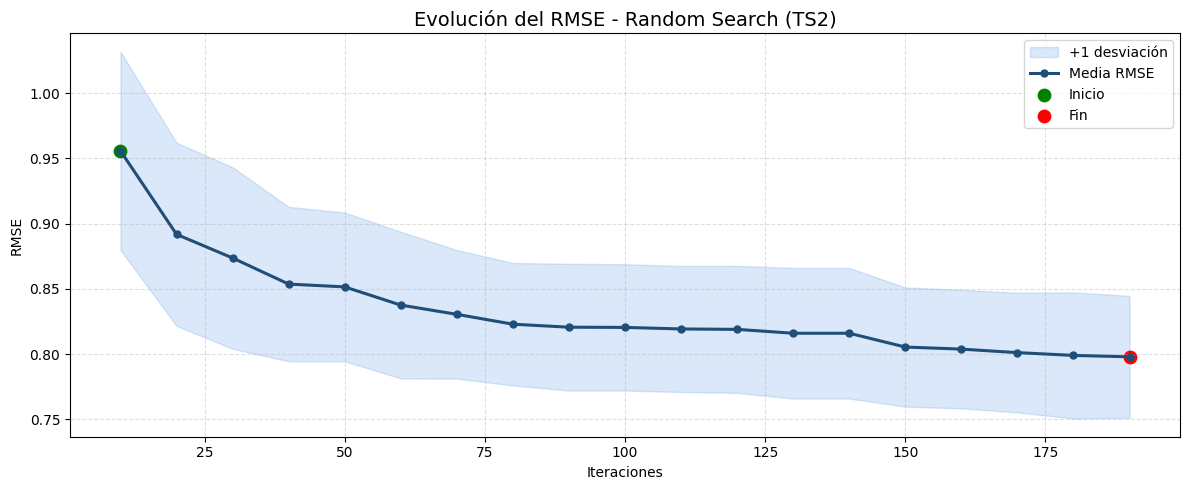

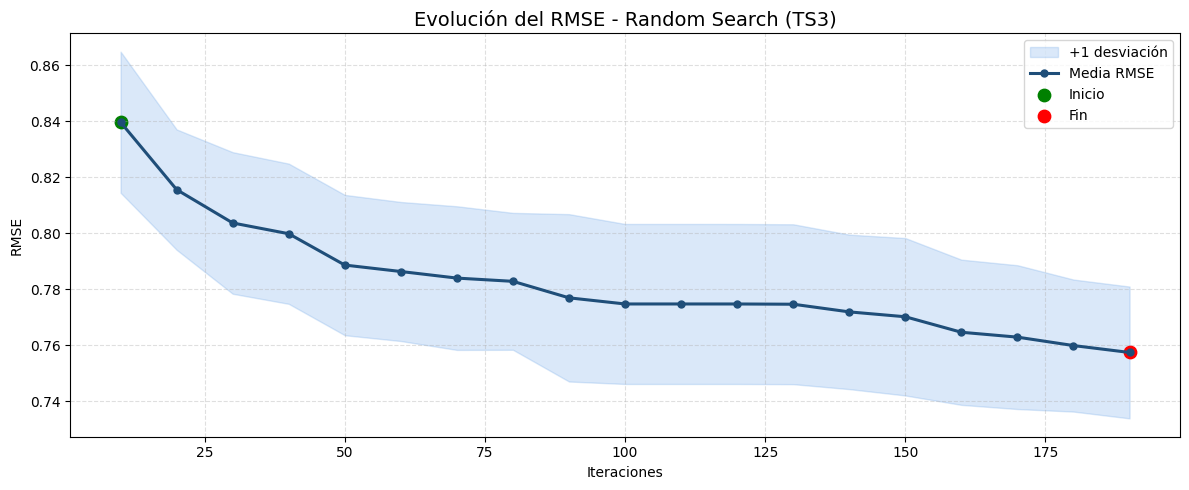

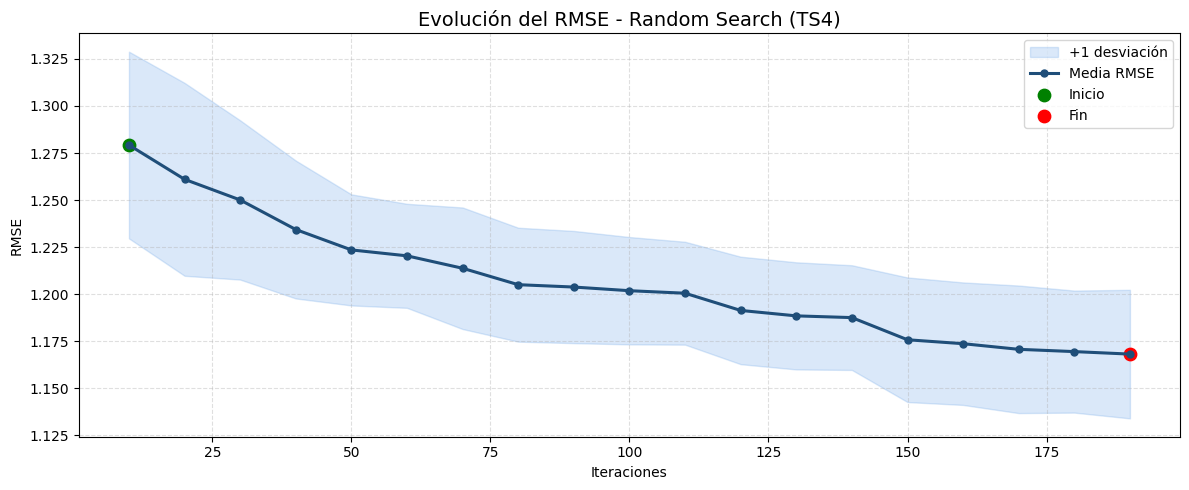

>>> Gráficas generadas correctamente.


In [14]:
plot_RS(series, resultados_RS)

### 9.2 Representación gráfica de la segmentación final

Además de analizar la evolución del RMSE a lo largo de las iteraciones, es importante visualizar la **solución final** obtenida por el algoritmo de Búsqueda Aleatoria. 

Para cada serie temporal (TS1–TS4), se representa:

- La **serie real** (en azul).
- La **serie estimada** a partir de los segmentos óptimos (en rojo).
- Las **líneas verticales** que indican los puntos de corte seleccionados por el algoritmo.

Estas gráficas permiten comprobar visualmente si las rectas ajustadas siguen adecuadamente la forma de la serie y si la segmentación obtenida es coherente con la estructura de los datos. Además, facilitan la comparación posterior con las soluciones obtenidas mediante Hill Climbing y Simulated Annealing.

In [15]:
def plot_final_solutions(series, resultados, k_values):
    for idx, serie in enumerate(series):
        best_points = resultados[-1][idx][-1]["points"]

        coef = estimate_all_coef(serie, best_points.copy())
        estimada = estimate_all_points(coef, best_points.copy(), len(serie))

        plt.figure(figsize=(12, 5))
        plt.plot(serie, label="Serie real", color="blue")
        plt.plot(estimada, label="Serie estimada", color="red")

        for p in best_points:
            plt.axvline(x=p, color="black", linestyle="--", alpha=0.7)

        plt.title(f"Solución final RS - TS{idx+1} (k={k_values[idx]})")
        plt.xlabel("Tiempo")
        plt.ylabel("Valor")
        plt.legend()
        plt.grid(True)
        
        plt.savefig(f"RS_TS{idx+1}_solucion_final.png", dpi=150)

        plt.show()

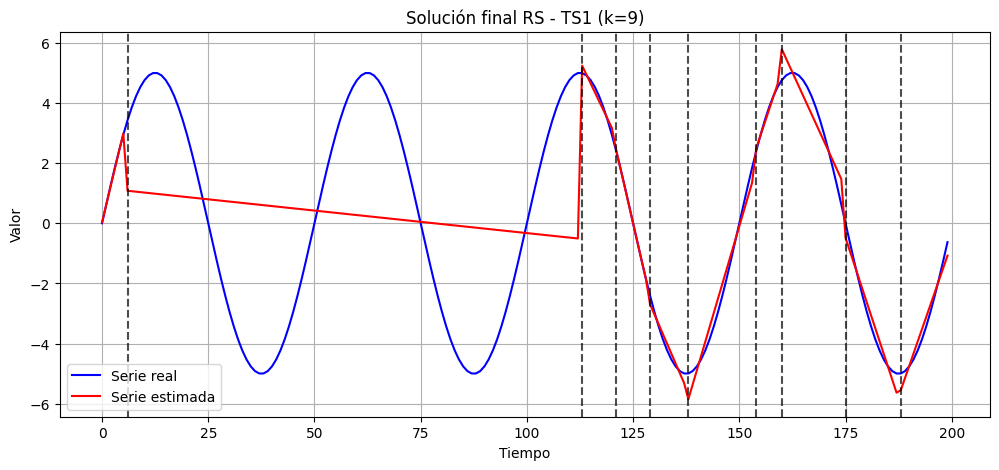

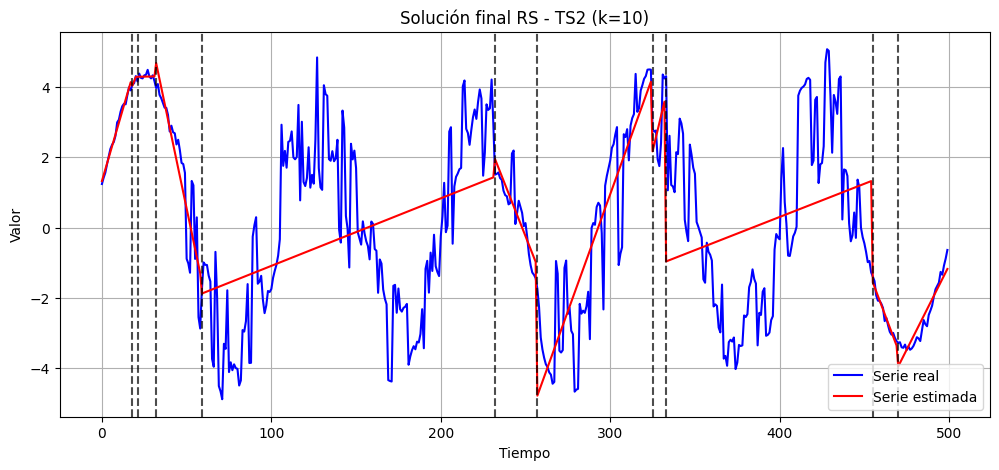

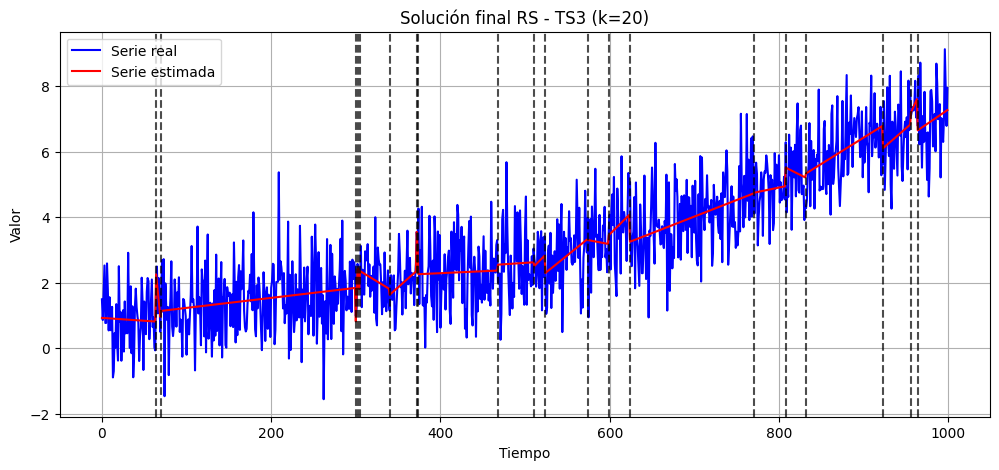

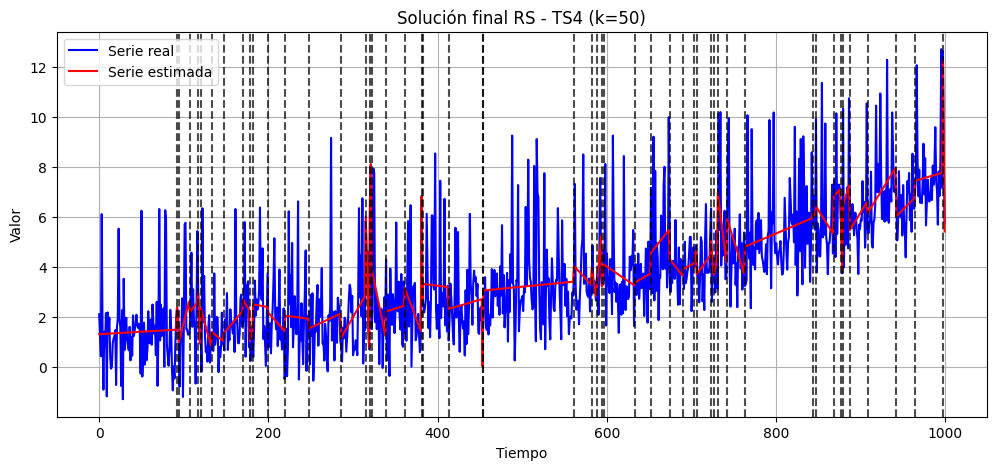

In [16]:
plot_final_solutions(series, resultados_RS, k_values)

## 10.  Obtención de métricas para comparar los tres algoritmos.

Para cada serie (TS1, TS2, TS3, TS4) y para cada algoritmo (RS, HC, SA), necesitamos:

**Exactitud**  
→ El RMSE medio final (cuanto más bajo, mejor)

**Variabilidad**  
→ La desviación típica del RMSE entre repeticiones  
(mide estabilidad)

**Tiempo de cómputo**  
→ El tiempo medio por repetición  
(mide eficiencia)

La función `ejecutar_RS` ya guarda:

- `"rmse"`  
- `"tiempo"`  
- `"points"`  
- `"iter"`

Y lo hace **para cada repetición**.

Así que solo necesitamos **procesar esos datos** para obtener:

- media del RMSE final  
- desviación típica del RMSE final  
- media del tiempo total  


### 10.1. EXTRAER EXACTITUD (RMSE final)

In [17]:
def exactitud_RS(resultados):
    medias = []
    for serie in range(len(resultados[0])):
        rmse_final = [rep[serie][-1]["rmse"] for rep in resultados]
        medias.append(np.mean(rmse_final))
    return medias


### 10.2. EXTRAER VARIABILIDAD (desviación típica)

In [18]:
def variabilidad_RS(resultados):
    desv = []
    for serie in range(len(resultados[0])):
        rmse_final = [rep[serie][-1]["rmse"] for rep in resultados]
        desv.append(np.std(rmse_final))
    return desv


### 10.3. EXTRAER TIEMPO DE CÓMPUTO

In [19]:
def tiempo_RS(resultados):
    tiempos = []
    for serie in range(len(resultados[0])):
        tiempo_total = [sum([it["tiempo"] for it in rep[serie]]) for rep in resultados]
        tiempos.append(np.mean(tiempo_total))
    return tiempos


### 10.4. CALCULAR MÉTRICAS

In [20]:
# Calcular métricas
rmse_medios = exactitud_RS(resultados_RS)
rmse_desv = variabilidad_RS(resultados_RS)
tiempos_medios = tiempo_RS(resultados_RS)

# Crear tabla
series = ["TS1 (k=9)", "TS2 (k=10)", "TS3 (k=20)", "TS4 (k=50)"]

tabla = pd.DataFrame({
    "Serie": series,
    "RMSE medio": rmse_medios,
    "Desviación típica": rmse_desv,
    "Tiempo medio (s)": tiempos_medios
})

from tabulate import tabulate
tabla_formateada = tabla.copy()
tabla_formateada["RMSE medio"] = tabla_formateada["RMSE medio"].map("{:.6f}".format)
tabla_formateada["Desviación típica"] = tabla_formateada["Desviación típica"].map("{:.6f}".format)
tabla_formateada["Tiempo medio (s)"] = tabla_formateada["Tiempo medio (s)"].map("{:.6f}".format)

print(tabulate(tabla_formateada, headers="keys", tablefmt="fancy_grid", showindex=False))

╒════════════╤══════════════╤═════════════════════╤════════════════════╕
│ Serie      │   RMSE medio │   Desviación típica │   Tiempo medio (s) │
╞════════════╪══════════════╪═════════════════════╪════════════════════╡
│ TS1 (k=9)  │     0.560176 │            0.039159 │           0.425418 │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS2 (k=10) │     0.797982 │            0.046689 │           0.471489 │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS3 (k=20) │     0.757383 │            0.023547 │           0.901699 │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS4 (k=50) │     1.16818  │            0.034155 │           2.08968  │
╘════════════╧══════════════╧═════════════════════╧════════════════════╛
